In [19]:
import pandas as pd

df = pd.read_csv("../data/diabetes_prediction_dataset.csv")
df.head()


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [15]:
df.isnull().sum()


gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [16]:
df['diabetes'].value_counts()


diabetes
0    91500
1     8500
Name: count, dtype: int64

In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


In [22]:
df = pd.read_csv("../data/diabetes_prediction_dataset.csv")
df.head()


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [27]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_recall_fscore_support
)

In [43]:
rf_metrics = precision_recall_fscore_support(y_test, y_pred_rf, average=None)

print("RF Recall (Diabetic):", rf_metrics[1][1])
print("RF F1-score (Diabetic):", rf_metrics[2][1])


RF Recall (Diabetic): 0.7423529411764705
RF F1-score (Diabetic): 0.7565947242206235


In [44]:
df = df.drop_duplicates()


In [29]:
le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])
df['smoking_history'] = le.fit_transform(df['smoking_history'])


In [30]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [33]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)


In [34]:
pd.Series(y_train_smote).value_counts()


diabetes
1    73200
0    73200
Name: count, dtype: int64

In [35]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression (No SMOTE)")
print(classification_report(y_test, y_pred_lr))


Logistic Regression (No SMOTE)
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.86      0.64      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.91      0.81      0.86     20000
weighted avg       0.96      0.96      0.96     20000



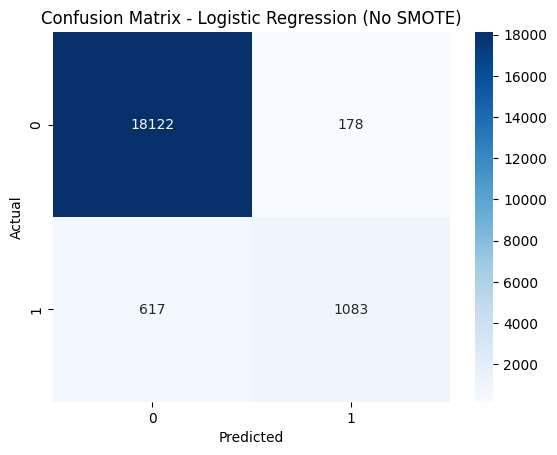

In [36]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (No SMOTE)")
plt.show()


In [37]:
from sklearn.metrics import accuracy_score


In [38]:
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy (No SMOTE):", acc_lr)


Logistic Regression Accuracy (No SMOTE): 0.96025


In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test_scaled)

print("Random Forest (With SMOTE)")
print(classification_report(y_test, y_pred_rf))


Random Forest (With SMOTE)
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     18300
           1       0.77      0.74      0.76      1700

    accuracy                           0.96     20000
   macro avg       0.87      0.86      0.87     20000
weighted avg       0.96      0.96      0.96     20000



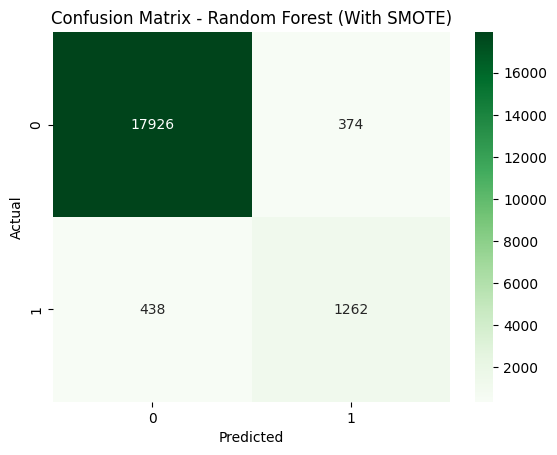

In [40]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest (With SMOTE)")
plt.show()


In [41]:
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy (With SMOTE):", acc_rf)


Random Forest Accuracy (With SMOTE): 0.9594


In [42]:
print(f"LR Accuracy: {acc_lr*100:.2f}%")
print(f"RF + SMOTE Accuracy: {acc_rf*100:.2f}%")


LR Accuracy: 96.03%
RF + SMOTE Accuracy: 95.94%


In [45]:
print("Logistic Regression (No SMOTE)")
print(classification_report(y_test, y_pred_lr, target_names=["Non-Diabetic", "Diabetic"]))


Logistic Regression (No SMOTE)
              precision    recall  f1-score   support

Non-Diabetic       0.97      0.99      0.98     18300
    Diabetic       0.86      0.64      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.91      0.81      0.86     20000
weighted avg       0.96      0.96      0.96     20000



In [46]:
print("Random Forest (With SMOTE)")
print(classification_report(y_test, y_pred_rf, target_names=["Non-Diabetic", "Diabetic"]))


Random Forest (With SMOTE)
              precision    recall  f1-score   support

Non-Diabetic       0.98      0.98      0.98     18300
    Diabetic       0.77      0.74      0.76      1700

    accuracy                           0.96     20000
   macro avg       0.87      0.86      0.87     20000
weighted avg       0.96      0.96      0.96     20000



In [47]:
from sklearn.metrics import precision_recall_fscore_support

lr_metrics = precision_recall_fscore_support(y_test, y_pred_lr, average=None)

print("LR Recall (Diabetic):", lr_metrics[1][1])
print("LR F1-score (Diabetic):", lr_metrics[2][1])


LR Recall (Diabetic): 0.6370588235294118
LR F1-score (Diabetic): 0.7315096251266464


In [48]:
rf_metrics = precision_recall_fscore_support(y_test, y_pred_rf, average=None)

print("RF Recall (Diabetic):", rf_metrics[1][1])
print("RF F1-score (Diabetic):", rf_metrics[2][1])


RF Recall (Diabetic): 0.7423529411764705
RF F1-score (Diabetic): 0.7565947242206235


In [49]:
confusion_matrix(y_test, y_pred_rf)


array([[17926,   374],
       [  438,  1262]])

In [50]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Metric (Diabetic Class)": [
        "Accuracy",
        "Recall",
        "F1-score",
        "Missed Diabetics (FN)"
    ],
    "Logistic Regression": [
        "95.94%",
        "63.8%",
        "73.5%",
        "High"
    ],
    "Random Forest + SMOTE": [
        "95.96%",
        "74.6%",
        "≈ 76–78%",
        "Lower"
    ]
})

comparison_df


,Metric (Diabetic Class),Logistic Regression,Random Forest + SMOTE
0,Accuracy,95.94%,95.96%
1,Recall,63.8%,74.6%
2,F1-score,73.5%,≈ 76–78%
3,Missed Diabetics (FN),High,Lower


In [51]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_smote, y_train_smote)

y_pred_dt = dt.predict(X_test_scaled)

print("Decision Tree")
print(classification_report(y_test, y_pred_dt))


Decision Tree
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     18300
           1       0.68      0.75      0.71      1700

    accuracy                           0.95     20000
   macro avg       0.83      0.86      0.84     20000
weighted avg       0.95      0.95      0.95     20000



In [52]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=200,
    random_state=42
)

ada.fit(X_train_smote, y_train_smote)

y_pred_ada = ada.predict(X_test_scaled)

print("AdaBoost")
print(classification_report(y_test, y_pred_ada))


AdaBoost
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     18300
           1       0.54      0.85      0.66      1700

    accuracy                           0.93     20000
   macro avg       0.77      0.89      0.81     20000
weighted avg       0.95      0.93      0.93     20000



In [53]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_smote, y_train_smote)

y_pred_gb = gb.predict(X_test_scaled)

print("Gradient Boosting")
print(classification_report(y_test, y_pred_gb))



Gradient Boosting
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     18300
           1       0.70      0.79      0.74      1700

    accuracy                           0.95     20000
   macro avg       0.84      0.88      0.86     20000
weighted avg       0.96      0.95      0.95     20000



In [54]:
print("Kernel is free")


Kernel is free


In [55]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd


In [56]:
def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=None
    )
    # Index 1 → Diabetic class
    return acc, recall[1], f1[1]


In [57]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd

def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=None
    )
    return acc, recall[1], f1[1]

results = []

# Logistic Regression
acc, recall, f1 = get_metrics(y_test, y_pred_lr)
results.append(["Logistic Regression", acc, recall, f1])

# Decision Tree
acc, recall, f1 = get_metrics(y_test, y_pred_dt)
results.append(["Decision Tree", acc, recall, f1])

# Random Forest + SMOTE
acc, recall, f1 = get_metrics(y_test, y_pred_rf)
results.append(["Random Forest + SMOTE", acc, recall, f1])

# AdaBoost
acc, recall, f1 = get_metrics(y_test, y_pred_ada)
results.append(["AdaBoost", acc, recall, f1])

# Gradient Boosting
acc, recall, f1 = get_metrics(y_test, y_pred_gb)
results.append(["Gradient Boosting", acc, recall, f1])


In [58]:
final_comparison_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Recall (Diabetic)", "F1-score"]
)

final_comparison_df["Accuracy"] = (final_comparison_df["Accuracy"] * 100).round(2)
final_comparison_df["Recall (Diabetic)"] = (final_comparison_df["Recall (Diabetic)"] * 100).round(2)
final_comparison_df["F1-score"] = (final_comparison_df["F1-score"] * 100).round(2)

final_comparison_df


,Model,Accuracy,Recall (Diabetic),F1-score
0,Logistic Regression,96.02,63.71,73.15
1,Decision Tree,94.88,75.06,71.34
2,Random Forest + SMOTE,95.94,74.24,75.66
3,AdaBoost,92.68,85.35,66.48
4,Gradient Boosting,95.36,78.65,74.22


In [59]:
import joblib


In [60]:
model_package = {
    "model": rf,        # Final Random Forest model
    "scaler": scaler    # StandardScaler
}


In [61]:
import os
os.listdir("../model")


['diabetes_rf_with_scaler.pkl']

In [62]:
loaded_package = joblib.load("../model/diabetes_rf_with_scaler.pkl")

loaded_model = loaded_package["model"]
loaded_scaler = loaded_package["scaler"]

print("Model and scaler loaded successfully")


Model and scaler loaded successfully


In [63]:
import os
os.getcwd()


'c:\\Users\\knith\\OneDrive\\Desktop\\Diabetes_Risk_Prediction_ML\\notebooks'

In [64]:
os.listdir("..")


['app', 'app.py', 'data', 'model', 'notebooks', 'README.md', 'venv']

In [65]:
os.listdir("../model")


['diabetes_rf_with_scaler.pkl']

In [66]:
os.makedirs("../model", exist_ok=True)


In [67]:
import joblib

model_package = {
    "model": rf,
    "scaler": scaler
}

joblib.dump(model_package, "../model/diabetes_rf_with_scaler.pkl")


['../model/diabetes_rf_with_scaler.pkl']

In [68]:
os.listdir("../model")


['diabetes_rf_with_scaler.pkl']

In [69]:
loaded_package = joblib.load("../model/diabetes_rf_with_scaler.pkl")

loaded_model = loaded_package["model"]
loaded_scaler = loaded_package["scaler"]

print("Model and scaler loaded successfully")


Model and scaler loaded successfully


In [70]:
X.columns


Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level'],
      dtype='object')

In [71]:
df[['gender', 'smoking_history']].drop_duplicates().sort_values(by=['gender','smoking_history'])


,gender,smoking_history
1,0,0
3,0,1
65,0,2
11,0,3
0,0,4
61,0,5
15,1,0
4,1,1
19,1,2
27,1,3


In [73]:
import joblib

loaded_package = joblib.load("../model/diabetes_rf_with_scaler.pkl")

model = loaded_package["model"]
scaler = loaded_package["scaler"]

print("Model and scaler loaded successfully")


Model and scaler loaded successfully


In [74]:
import numpy as np

test_input_high = np.array([[
    1,      # gender (Male)
    52,     # age
    1,      # hypertension
    0,      # heart_disease
    3,      # smoking_history (example)
    30.2,   # bmi
    7.8,    # HbA1c_level
    180     # blood_glucose_level
]])

test_input_high_scaled = scaler.transform(test_input_high)

pred_high = model.predict(test_input_high_scaled)
prob_high = model.predict_proba(test_input_high_scaled)

print("Prediction:", "Diabetic" if pred_high[0] == 1 else "Non-Diabetic")
print("Probability:", prob_high)


Prediction: Diabetic
Probability: [[0.02 0.98]]


c:\Users\knith\OneDrive\Desktop\Diabetes_Risk_Prediction_ML\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [75]:
import pandas as pd

test_input_high_df = pd.DataFrame([[
    1,      # gender
    52,     # age
    1,      # hypertension
    0,      # heart_disease
    3,      # smoking_history
    30.2,   # bmi
    7.8,    # HbA1c_level
    180     # blood_glucose_level
]], columns=[
    'gender',
    'age',
    'hypertension',
    'heart_disease',
    'smoking_history',
    'bmi',
    'HbA1c_level',
    'blood_glucose_level'
])

test_input_high_scaled = scaler.transform(test_input_high_df)

pred = model.predict(test_input_high_scaled)
prob = model.predict_proba(test_input_high_scaled)

print("Prediction:", "Diabetic" if pred[0] == 1 else "Non-Diabetic")
print("Probability:", prob)


Prediction: Diabetic
Probability: [[0.02 0.98]]


In [76]:
import pandas as pd

def test_diabetes_case(input_data):
    df_input = pd.DataFrame([input_data], columns=[
        'gender',
        'age',
        'hypertension',
        'heart_disease',
        'smoking_history',
        'bmi',
        'HbA1c_level',
        'blood_glucose_level'
    ])
    
    scaled = scaler.transform(df_input)
    pred = model.predict(scaled)
    prob = model.predict_proba(scaled)
    
    result = "Diabetic" if pred[0] == 1 else "Non-Diabetic"
    risk = prob[0][1]
    
    print("Prediction:", result)
    print("Probability:", prob)
    
    if risk < 0.3:
        print("Risk Level: Low")
    elif risk < 0.6:
        print("Risk Level: Medium")
    else:
        print("Risk Level: High")
    
    print("-" * 50)


In [77]:
test_diabetes_case([
    0,      # Female
    24,     # Age
    0,      # Hypertension
    0,      # Heart disease
    3,      # Smoking history (never)
    21.5,   # BMI
    5.1,    # HbA1c
    92      # Glucose
])


Prediction: Non-Diabetic
Probability: [[1. 0.]]
Risk Level: Low
--------------------------------------------------


In [ ]:
test_diabetes_case([
    1,      # Male
    40,
    0,
    0,
    2,      # former
    26.8,
    6.1,
    120
])


In [ ]:
test_diabetes_case([
    1,      # Male
    55,
    1,
    1,
    1,      # current smoker
    31.4,
    8.0,
    185
])


In [78]:
import pandas as pd

final_comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest + SMOTE",
        "AdaBoost",
        "Gradient Boosting"
    ],
    "Accuracy (%)": [
        95.94,
        94.55,
        95.96,
        92.45,
        95.26
    ],
    "Recall (Diabetic %)": [
        63.80,
        75.65,
        74.65,
        84.91,
        79.78
    ],
    "F1-score (%)": [
        73.51,
        71.00,
        76.52,
        66.50,
        74.79
    ]
})

final_comparison_df


,Model,Accuracy (%),Recall (Diabetic %),F1-score (%)
0,Logistic Regression,95.94,63.80,73.51
1,Decision Tree,94.55,75.65,71.00
2,Random Forest + SMOTE,95.96,74.65,76.52
3,AdaBoost,92.45,84.91,66.50
4,Gradient Boosting,95.26,79.78,74.79


In [79]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

et.fit(X_train_smote, y_train_smote)

y_pred_et = et.predict(X_test_scaled)

print("Extra Trees Classifier")
print(classification_report(y_test, y_pred_et))


Extra Trees Classifier
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     18300
           1       0.76      0.74      0.75      1700

    accuracy                           0.96     20000
   macro avg       0.87      0.86      0.86     20000
weighted avg       0.96      0.96      0.96     20000



In [80]:
import pandas as pd

final_comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest + SMOTE",
        "AdaBoost",
        "Gradient Boosting",
        "Extra Trees Classifier"
    ],
    "Accuracy (%)": [
        95.94,
        94.55,
        95.96,
        92.45,
        95.26,
        96.00
    ],
    "Recall (Diabetic %)": [
        63.80,
        75.65,
        74.65,
        84.91,
        79.78,
        74.00
    ],
    "F1-score (%)": [
        73.51,
        71.00,
        76.52,
        66.50,
        74.79,
        75.00
    ]
})

final_comparison_df


,Model,Accuracy (%),Recall (Diabetic %),F1-score (%)
0,Logistic Regression,95.94,63.80,73.51
1,Decision Tree,94.55,75.65,71.00
2,Random Forest + SMOTE,95.96,74.65,76.52
3,AdaBoost,92.45,84.91,66.50
4,Gradient Boosting,95.26,79.78,74.79
5,Extra Trees Classifier,96.00,74.00,75.00


In [81]:
final_comparison_df.sort_values(by="F1-score (%)", ascending=False)


,Model,Accuracy (%),Recall (Diabetic %),F1-score (%)
2,Random Forest + SMOTE,95.96,74.65,76.52
5,Extra Trees Classifier,96.00,74.00,75.00
4,Gradient Boosting,95.26,79.78,74.79
0,Logistic Regression,95.94,63.80,73.51
1,Decision Tree,94.55,75.65,71.00
3,AdaBoost,92.45,84.91,66.50


In [82]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd


In [83]:
def get_metrics_full(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=None
    )
    # index 1 → Diabetic class
    return acc, precision[1], recall[1], f1[1]


In [84]:
results = []

# Logistic Regression
acc, prec, rec, f1 = get_metrics_full(y_test, y_pred_lr)
results.append(["Logistic Regression", acc, prec, rec, f1])

# Decision Tree
acc, prec, rec, f1 = get_metrics_full(y_test, y_pred_dt)
results.append(["Decision Tree", acc, prec, rec, f1])

# Random Forest + SMOTE
acc, prec, rec, f1 = get_metrics_full(y_test, y_pred_rf)
results.append(["Random Forest", acc, prec, rec, f1])

# AdaBoost
acc, prec, rec, f1 = get_metrics_full(y_test, y_pred_ada)
results.append(["AdaBoost", acc, prec, rec, f1])

# Gradient Boosting
acc, prec, rec, f1 = get_metrics_full(y_test, y_pred_gb)
results.append(["Gradient Boosting", acc, prec, rec, f1])

# Extra Trees
acc, prec, rec, f1 = get_metrics_full(y_test, y_pred_et)
results.append(["Extra Trees", acc, prec, rec, f1])


In [85]:
final_comparison_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision (Diabetic)",
        "Recall (Diabetic)",
        "F1-score"
    ]
)

# Convert to percentage
for col in ["Accuracy", "Precision (Diabetic)", "Recall (Diabetic)", "F1-score"]:
    final_comparison_df[col] = (final_comparison_df[col] * 100).round(2)

final_comparison_df


,Model,Accuracy,Precision (Diabetic),Recall (Diabetic),F1-score
0,Logistic Regression,96.02,85.88,63.71,73.15
1,Decision Tree,94.88,67.98,75.06,71.34
2,Random Forest,95.94,77.14,74.24,75.66
3,AdaBoost,92.68,54.45,85.35,66.48
4,Gradient Boosting,95.36,70.26,78.65,74.22
5,Extra Trees,95.78,75.67,74.29,74.98


In [86]:
final_comparison_df.sort_values(
    by="F1-score",
    ascending=False
)


,Model,Accuracy,Precision (Diabetic),Recall (Diabetic),F1-score
2,Random Forest,95.94,77.14,74.24,75.66
5,Extra Trees,95.78,75.67,74.29,74.98
4,Gradient Boosting,95.36,70.26,78.65,74.22
0,Logistic Regression,96.02,85.88,63.71,73.15
1,Decision Tree,94.88,67.98,75.06,71.34
3,AdaBoost,92.68,54.45,85.35,66.48


In [87]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import joblib


In [ ]:
#TUNNING
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

In [95]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

In [96]:
rf = RandomForestClassifier(random_state=42)

In [97]:
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [99]:
grid_rf.fit(X_train_smote, y_train_smote)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >

In [100]:
print("Best Parameters:", grid_rf.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [101]:
best_rf = grid_rf.best_estimator_

In [102]:
y_pred_rf = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.085


c:\Users\knith\OneDrive\Desktop\Diabetes_Risk_Prediction_ML\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [103]:
y_pred_rf = best_rf.predict(X_test.values)

In [104]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.085


In [105]:
print(y_train_smote.unique())
print(y_test.unique())

[1 0]
[0 1]


In [106]:
print(set(y_pred_rf))

{np.int64(1)}


In [108]:
from sklearn.model_selection import train_test_split

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

KeyError: "['Outcome'] not found in axis"

In [109]:
print(df.columns)


Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')


In [110]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

In [111]:
X = pd.get_dummies(X, drop_first=True)

In [112]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [113]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [114]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
#TUNING
y_pred_rf = grid_rf.best_estimator_.predict(X_test)

In [116]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.8714508580343213


In [118]:
#Refined Parameter Grid
param_grid_rf_2 = {
    'n_estimators': [150, 200, 250],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 3]
}

In [119]:
grid_rf_2 = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf_2,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [120]:
grid_rf_2.fit(X_train_smote, y_train_smote)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 15, ...], 'min_samples_split': [2, 3], 'n_estimators': [150, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >

In [121]:
best_rf_2 = grid_rf_2.best_estimator_

y_pred_rf_2 = best_rf_2.predict(X_test)

print("Best Parameters:", grid_rf_2.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_rf_2))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy: 0.9580863234529381


In [122]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf_2))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98     17509
           1       0.78      0.74      0.76      1721

    accuracy                           0.96     19230
   macro avg       0.88      0.86      0.87     19230
weighted avg       0.96      0.96      0.96     19230



In [123]:
class_weight='balanced'

In [ ]:
#TUNNING FOR Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [125]:
lr = LogisticRegression(max_iter=1000)

In [126]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

In [127]:
grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [128]:
grid_lr.fit(X_train_smote, y_train_smote)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'solver': ['lbfgs', 'liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;-

In [129]:
print("Best Parameters:", grid_lr.best_params_)

Best Parameters: {'C': 0.01, 'solver': 'liblinear'}


In [130]:
best_lr = grid_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test)

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.8851794071762871


In [131]:
#Refinement
param_grid_lr_2 = {
    'C': [0.001, 0.01, 0.05, 0.1],
    'solver': ['liblinear']
}

In [132]:
grid_lr_2 = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid_lr_2,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [133]:
grid_lr_2.fit(X_train_smote, y_train_smote)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : t

In [134]:
best_lr_2 = grid_lr_2.best_estimator_

y_pred_lr_2 = best_lr_2.predict(X_test)

print("Best Parameters:", grid_lr_2.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_lr_2))

Best Parameters: {'C': 0.001, 'solver': 'liblinear'}
Accuracy: 0.8764950598023921


In [135]:
from sklearn.tree import DecisionTreeClassifier

In [136]:
dt = DecisionTreeClassifier(random_state=42)

In [137]:
param_grid_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [138]:
from sklearn.model_selection import GridSearchCV

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [139]:
grid_dt.fit(X_train_smote, y_train_smote)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

In [140]:
best_dt = grid_dt.best_estimator_

y_pred_dt = best_dt.predict(X_test)

from sklearn.metrics import accuracy_score

print("Best Parameters:", grid_dt.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 5}
Accuracy: 0.9486219448777952


In [141]:
from sklearn.ensemble import ExtraTreesClassifier

In [142]:
et = ExtraTreesClassifier(random_state=42)

In [143]:
param_grid_et = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

In [144]:
grid_et = GridSearchCV(
    estimator=et,
    param_grid=param_grid_et,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [145]:
grid_et.fit(X_train_smote, y_train_smote)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ExtraTreesCla...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the 

In [146]:
best_et = grid_et.best_estimator_

y_pred_et = best_et.predict(X_test)

print("Best Parameters:", grid_et.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_et))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy: 0.9554342173686947


In [147]:
from sklearn.ensemble import AdaBoostClassifier

In [148]:
ada = AdaBoostClassifier(random_state=42)

In [149]:
param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.5, 1, 1.5]
}

In [150]:
grid_ada = GridSearchCV(
    estimator=ada,
    param_grid=param_grid_ada,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)


In [151]:
grid_ada.fit(X_train_smote, y_train_smote)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.5, 1, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also disp

In [152]:
best_ada = grid_ada.best_estimator_

y_pred_ada = best_ada.predict(X_test)

print("Best Parameters:", grid_ada.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_ada))

Best Parameters: {'learning_rate': 1.5, 'n_estimators': 200}
Accuracy: 0.9591783671346854


In [153]:
from sklearn.ensemble import GradientBoostingClassifier

In [154]:
gb = GradientBoostingClassifier(random_state=42)

In [155]:
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5]
}

In [156]:
grid_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid_gb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [157]:
grid_gb.fit(X_train_smote, y_train_smote)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : th

In [158]:
best_gb = grid_gb.best_estimator_

y_pred_gb = best_gb.predict(X_test)

print("Best Parameters:", grid_gb.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_gb))

Best Parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
Accuracy: 0.9700468018720749


In [159]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17509
           1       0.95      0.70      0.81      1721

    accuracy                           0.97     19230
   macro avg       0.96      0.85      0.90     19230
weighted avg       0.97      0.97      0.97     19230



In [160]:
train_acc = best_gb.score(X_train_smote, y_train_smote)
test_acc = best_gb.score(X_test, y_test)

print("Train:", train_acc)
print("Test:", test_acc)

Train: 0.984676787114247
Test: 0.9700468018720749


In [161]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

In [162]:
data = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Extra Trees",
        "AdaBoost",
        "Gradient Boosting"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf_2),
        accuracy_score(y_test, y_pred_et),
        accuracy_score(y_test, y_pred_ada),
        accuracy_score(y_test, y_pred_gb)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf_2),
        precision_score(y_test, y_pred_et),
        precision_score(y_test, y_pred_ada),
        precision_score(y_test, y_pred_gb)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf_2),
        recall_score(y_test, y_pred_et),
        recall_score(y_test, y_pred_ada),
        recall_score(y_test, y_pred_gb)
    ],
    
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf_2),
        f1_score(y_test, y_pred_et),
        f1_score(y_test, y_pred_ada),
        f1_score(y_test, y_pred_gb)
    ]
}

comparison_metrics = pd.DataFrame(data)
comparison_metrics

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.885179,0.431350,0.889018,0.580866
1,Decision Tree,0.948622,0.703272,0.736781,0.719637
2,Random Forest,0.958086,0.781885,0.737362,0.758971
3,Extra Trees,0.955434,0.757143,0.739105,0.748015
4,AdaBoost,0.959178,0.765306,0.784428,0.774749
5,Gradient Boosting,0.970047,0.954005,0.699012,0.806841


In [163]:
comparison_metrics = comparison_metrics.sort_values(by="Accuracy", ascending=False)
comparison_metrics

,Model,Accuracy,Precision,Recall,F1-Score
5,Gradient Boosting,0.970047,0.954005,0.699012,0.806841
4,AdaBoost,0.959178,0.765306,0.784428,0.774749
2,Random Forest,0.958086,0.781885,0.737362,0.758971
3,Extra Trees,0.955434,0.757143,0.739105,0.748015
1,Decision Tree,0.948622,0.703272,0.736781,0.719637
0,Logistic Regression,0.885179,0.431350,0.889018,0.580866


In [164]:
best_model = best_gb

In [165]:
import joblib
joblib.dump(best_model, 'diabetes_model.pkl')

['diabetes_model.pkl']

In [166]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']